# Spinal Curvature Estimation — Back Surface Geometry
**Version:** Fixed v2 — arm outlier rejection, dark-background segmentation, stable polynomial

**Bugs fixed from v1:**
- Swinging arm was being detected as back surface → wild curve and 150+ deg readings
- GrabCut was failing on dark backgrounds → replaced with threshold + largest-contour
- Polynomial fitting on outlier points → added IQR-based outlier rejection before fitting

**Works on:**
- Side-view video, any background
- No markers, no X-ray, no special equipment
- Walking or standing subjects

---
**Run every cell in order. Do not skip.**

## Cell 1 — Install and verify libraries

In [ ]:
import subprocess
import sys
import os

def install_and_restart():
    print("--- Fixing environment: Uninstalling conflicting packages ---")
    pkgs = ['numpy', 'scipy', 'opencv-python-headless', 'matplotlib']
    for pkg in pkgs:
        subprocess.run([sys.executable, '-m', 'pip', 'uninstall', pkg, '-y', '-q'])

    print("--- Installing compatible versions (NumPy < 2.0) ---")
    # Pinning numpy < 2.0 to avoid the 'show_config' and 'blas' attribute errors in SciPy/OpenCV
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'numpy<2.0.0', 'scipy==1.11.4', 'opencv-python-headless', 'matplotlib', '-q'])

    print("\n!!! RESTARTING RUNTIME TO APPLY CHANGES !!!")
    print("Please wait for reconnection, then proceed to the next cell.")
    os.kill(os.getpid(), 9)

try:
    import numpy as np
    import scipy
    # Test if the specific failing attribute exists
    from numpy.__config__ import show_config
    print(f"Environment OK: NumPy {np.__version__}, SciPy {scipy.__version__}")
except (ImportError, AttributeError):
    install_and_restart()


--- Fixing environment: Uninstalling conflicting packages ---
--- Installing compatible versions (NumPy < 2.0) ---


## Cell 2 — Upload your video

In [1]:
from google.colab import files
import os, cv2

print('Click Choose Files and upload your side-view walking video.')
uploaded   = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]

cap   = cv2.VideoCapture(VIDEO_PATH)
FPS   = cap.get(cv2.CAP_PROP_FPS)
W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f'Video  : {VIDEO_PATH}  ({os.path.getsize(VIDEO_PATH)/1024/1024:.1f} MB)')
print(f'Size   : {W} x {H} px')
print(f'FPS    : {FPS:.2f}')
print(f'Frames : {TOTAL}  ({TOTAL/FPS:.1f} seconds)')

Click Choose Files and upload your side-view walking video.


Saving video5943058981776796129.mp4 to video5943058981776796129.mp4
Video  : video5943058981776796129.mp4  (0.7 MB)
Size   : 560 x 640 px
FPS    : 30.00
Frames : 276  (9.2 seconds)


## Cell 3 — Configuration

In [2]:
# ── Output files ──────────────────────────────────────────────────
OUTPUT_VIDEO = 'output_kyphosis_fixed.mp4'
OUTPUT_PLOT  = 'kyphosis_analysis_fixed.png'

# ── Subject ───────────────────────────────────────────────────────
SUBJECT_SEX = 'male'      # change to 'female' if needed
SUBJECT_ID  = 'Subject_01'

# ── Normative reference (Ohlendorf et al., 2023) ──────────────────
NORM_KYPHOSIS = {'female': 56, 'male': 51}
NORM_STD      = {'female': 10, 'male': 10}

# ── Kyphosis classification thresholds (degrees) ──────────────────
THRESH_MILD   = 20   # < 20 = Normal
THRESH_SEVERE = 40   # 20-40 = Mild,  > 40 = Severe

# ── Segmentation: background threshold ────────────────────────────
# For DARK background (black/grey): use 60
# For LIGHT background (white/bright): use 180
# For MIXED/OUTDOOR background: use 0 (auto = GrabCut)
BG_THRESHOLD = 60

# ── Body proportion estimates ─────────────────────────────────────
SHOULDER_FRAC = 0.18   # shoulder level = 18% from top of bounding box
HIP_FRAC      = 0.65   # hip level      = 65% from top of bounding box

# ── Curve fitting ────────────────────────────────────────────────
POLY_DEGREE   = 4     # polynomial degree (4 is recommended)
SMOOTH_FRAMES = 9     # temporal smoothing window

norm_val = NORM_KYPHOSIS[SUBJECT_SEX]
norm_std = NORM_STD[SUBJECT_SEX]
print(f'Subject         : {SUBJECT_ID} ({SUBJECT_SEX})')
print(f'Background mode : threshold={BG_THRESHOLD} (60=dark bg, 180=light bg, 0=auto)')
print(f'Normative value : {norm_val} +/- {norm_std} deg  (Ohlendorf et al., 2023)')
print(f'Classification  : Normal < {THRESH_MILD} deg | Mild {THRESH_MILD}-{THRESH_SEVERE} deg | Severe > {THRESH_SEVERE} deg')

Subject         : Subject_01 (male)
Background mode : threshold=60 (60=dark bg, 180=light bg, 0=auto)
Normative value : 51 +/- 10 deg  (Ohlendorf et al., 2023)
Classification  : Normal < 20 deg | Mild 20-40 deg | Severe > 40 deg


## Cell 4 — All pipeline functions (fully fixed)

In [3]:
import cv2
import numpy as np
from scipy.signal import savgol_filter


def extract_person_mask(frame, W, H, bg_threshold):
    """
    Extracts person silhouette.

    Strategy depends on bg_threshold:
    - bg_threshold > 0 : simple brightness threshold (works for dark or
      light uniform backgrounds). Keeps only the largest connected region.
    - bg_threshold = 0 : falls back to GrabCut (better for complex/outdoor
      backgrounds but slower).

    Always returns a binary mask where 255 = person.
    """
    gray   = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))

    if bg_threshold > 0:
        # Threshold: pixels brighter than bg_threshold = person
        _, mask = cv2.threshold(gray, bg_threshold, 255, cv2.THRESH_BINARY)
    else:
        # GrabCut for complex backgrounds
        mask_gc = np.zeros((H, W), np.uint8)
        bgd = np.zeros((1, 65), np.float64)
        fgd = np.zeros((1, 65), np.float64)
        rect = (20, 10, W - 40, H - 20)
        try:
            cv2.grabCut(frame, mask_gc, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
            mask = np.where((mask_gc == 2) | (mask_gc == 0), 0, 255).astype(np.uint8)
        except Exception:
            blur = cv2.GaussianBlur(gray, (11, 11), 0)
            _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological cleanup
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)

    # ── CRITICAL FIX: keep only the largest connected region ─────
    # This removes isolated noise blobs (hair, shoes, background patches)
    # that would otherwise be picked up as back contour points.
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean = np.zeros_like(mask)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean, [largest], -1, 255, -1)
    return clean


def get_person_bbox(mask):
    """Bounding box (x0, y0, x1, y1) of the person silhouette."""
    cols = np.where(mask.any(axis=0))[0]
    rows = np.where(mask.any(axis=1))[0]
    if not len(cols) or not len(rows):
        return None
    return int(cols[0]), int(rows[0]), int(cols[-1]), int(rows[-1])


def get_back_contour(mask, H, W, y_start, y_end):
    """
    Extracts the posterior (back) edge of the person silhouette
    between y_start (shoulder level) and y_end (hip level).

    Auto-detects which side is the back:
    - Person facing right -> back = LEFT edge of silhouette
    - Person facing left  -> back = RIGHT edge of silhouette

    Then applies IQR-based outlier rejection to remove arm/hand
    points that stick out beyond the smooth back surface.
    """
    # ── Detect facing direction ───────────────────────────────────
    upper_rows = range(max(0, int(y_start)),
                       min(H, int(y_start + (y_end - y_start) * 0.4)))
    upper_x = []
    for r in upper_rows:
        cs = np.where(mask[r, :] > 0)[0]
        if len(cs):
            upper_x.extend(cs.tolist())
    centroid_x = float(np.mean(upper_x)) if upper_x else W / 2
    use_left_edge = centroid_x < W * 0.5

    # ── Extract raw back edge ─────────────────────────────────────
    raw_pts = []
    for y in range(max(0, int(y_start)), min(H, int(y_end))):
        cs = np.where(mask[y, :] > 0)[0]
        if len(cs) >= 2:
            bx = int(cs[0]) if use_left_edge else int(cs[-1])
            raw_pts.append((bx, y))

    if len(raw_pts) < 10:
        return None

    raw_pts = np.array(raw_pts)

    # ── CRITICAL FIX: IQR outlier rejection ──────────────────────
    # Removes arm/hand points that stick out far beyond the back surface.
    # These cause the polynomial to spiral wildly and produce 150+ deg values.
    x_vals      = raw_pts[:, 0].astype(float)
    q25, q75    = np.percentile(x_vals, 25), np.percentile(x_vals, 75)
    iqr         = q75 - q25
    lo          = q25 - 1.5 * iqr
    hi          = q75 + 1.5 * iqr
    good        = (x_vals >= lo) & (x_vals <= hi)
    clean_pts   = raw_pts[good]

    return clean_pts if len(clean_pts) >= 10 else None


def fit_spine_curve(back_pts, degree=4):
    """
    Fits a polynomial of given degree to the back contour.
    Models x = f(y) — better than y=f(x) for near-vertical spines.
    Applies Savitzky-Golay smoothing before fitting.
    Returns (y_values, x_fitted, polynomial_object).
    """
    if back_pts is None or len(back_pts) < 10:
        return None, None, None

    y_vals = back_pts[:, 1].astype(float)
    x_vals = back_pts[:, 0].astype(float)

    n    = len(x_vals)
    wlen = min(11, n - (0 if n % 2 == 1 else 1))
    wlen = max(wlen, 5)
    x_sm = savgol_filter(x_vals, wlen, 3) if n > wlen else x_vals

    try:
        poly = np.poly1d(np.polyfit(y_vals, x_sm, degree))
        return y_vals, poly(y_vals), poly
    except Exception:
        return None, None, None


def compute_kyphosis_angle(poly, y_top, y_bottom):
    """
    Cobb-style kyphosis angle from the fitted back-surface curve.
    Measures the tangent angle at y_top (upper thoracic) and
    y_bottom (lower thoracic), then returns the difference.
    This represents how much the back curves between those two levels.
    """
    if poly is None:
        return 0.0
    dp      = poly.deriv()
    angle_t = np.degrees(np.arctan(abs(float(dp(y_top)))))
    angle_b = np.degrees(np.arctan(abs(float(dp(y_bottom)))))
    return float(abs(angle_t - angle_b))


def compute_max_curvature(poly, y_vals):
    """
    Maximum curvature kappa = |x''| / (1 + x'^2)^1.5
    Larger value = tighter bend = more severe kyphosis.
    """
    if poly is None or y_vals is None:
        return 0.0, 0.0
    dp  = poly.deriv(1)
    d2p = poly.deriv(2)
    ks  = [abs(float(d2p(y))) / (1 + float(dp(y))**2)**1.5 for y in y_vals]
    return float(np.max(ks)), float(np.mean(ks))


def classify_kyphosis(angle, thresh_mild, thresh_severe):
    if angle < thresh_mild:
        return 'Normal posture',  (0, 210, 100)
    elif angle < thresh_severe:
        return 'Mild kyphosis',   (0, 165, 255)
    else:
        return 'Severe kyphosis', (0, 50,  255)


def draw_frame_overlay(frame, mask, back_pts, poly,
                        y_start, y_end, kyphosis, curv_max,
                        W, H, thresh_mild, thresh_severe):
    """Draws silhouette tint, back contour dots, fitted curve, and text overlay."""
    out  = frame.copy()
    status, color = classify_kyphosis(kyphosis, thresh_mild, thresh_severe)

    # Silhouette tint
    tint = np.zeros_like(frame)
    tint[mask > 0] = [0, 45, 0]
    out = cv2.addWeighted(out, 0.88, tint, 0.12, 0)

    # Raw back contour (green dots, every 2nd point)
    if back_pts is not None:
        for bx, by in back_pts[::2]:
            cv2.circle(out, (int(bx), int(by)), 2, (0, 230, 80), -1)

    # Fitted curve (gradient blue->red top to bottom)
    if poly is not None:
        y_range = np.linspace(y_start, y_end, 100).astype(int)
        pts = []
        for y in y_range:
            x = int(poly(y))
            if 0 <= x < W and 0 <= int(y) < H:
                pts.append([x, int(y)])
        for i in range(len(pts) - 1):
            t     = i / max(len(pts) - 1, 1)
            color_curve = (int(255 * (1 - t)), 80, int(255 * t))
            cv2.line(out, tuple(pts[i]), tuple(pts[i + 1]), color_curve, 3)

    # Anchor points at shoulder and hip level
    if poly is not None:
        for y_a in [y_start, y_end]:
            xa = int(poly(y_a))
            if 0 <= xa < W and 0 <= int(y_a) < H:
                cv2.circle(out, (xa, int(y_a)), 9, (255, 230, 0), -1)
                cv2.circle(out, (xa, int(y_a)), 9, (0, 0, 0),     2)

    # Text overlay
    for text, col, yp in [
        (f'Kyphosis : {kyphosis:5.1f} deg', color,         32),
        (f'Max curv : {curv_max:.4f}',       (180,180,180), 58),
        (f'Status   : {status}',              color,         84),
    ]:
        cv2.putText(out, text, (10, yp), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (0,0,0), 4)
        cv2.putText(out, text, (10, yp), cv2.FONT_HERSHEY_SIMPLEX, 0.62, col,     2)

    return out


def smooth(arr, k=9):
    return np.convolve(arr, np.ones(k)/k, mode='same') if len(arr) >= k else np.array(arr)


print('All pipeline functions defined. Pipeline is fixed and ready.')

All pipeline functions defined. Pipeline is fixed and ready.


## Cell 5 — Process all video frames
Allow 5–15 minutes on Colab CPU for a 60-second video.

In [4]:
import cv2
import numpy as np

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out_v  = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, FPS, (W, H))

time_axis, kyph_raw, curv_max_list = [], [], []
skipped   = 0
frame_idx = 0

print(f'Processing {TOTAL} frames ({TOTAL/FPS:.1f}s)...')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    try:
        # 1. Extract person silhouette
        mask = extract_person_mask(frame, W, H, BG_THRESHOLD)
        bbox = get_person_bbox(mask)

        if bbox is None:
            skipped += 1
            out_v.write(frame)
            frame_idx += 1
            continue

        x0, y0, x1, y1 = bbox
        ph = y1 - y0
        if ph < 50:                  # person too small in frame
            skipped += 1
            out_v.write(frame)
            frame_idx += 1
            continue

        shoulder_y = y0 + ph * SHOULDER_FRAC
        hip_y      = y0 + ph * HIP_FRAC

        # 2. Extract back contour (with IQR outlier rejection)
        back_pts = get_back_contour(mask, H, W, shoulder_y, hip_y)

        if back_pts is None:
            skipped += 1
            out_v.write(frame)
            frame_idx += 1
            continue

        # 3. Fit polynomial curve
        y_vals, x_fit, poly = fit_spine_curve(back_pts, degree=POLY_DEGREE)

        if poly is None:
            skipped += 1
            out_v.write(frame)
            frame_idx += 1
            continue

        # 4. Compute kyphosis angle
        y_top    = shoulder_y + ph * 0.10
        y_bot    = hip_y      - ph * 0.10
        kyphosis = compute_kyphosis_angle(poly, y_top, y_bot)
        k_max, _ = compute_max_curvature(poly, y_vals)

        # Sanity check: reject physically impossible values
        if kyphosis > 90 or kyphosis < 0:
            skipped += 1
            out_v.write(frame)
            frame_idx += 1
            continue

        time_axis.append(frame_idx / FPS)
        kyph_raw.append(kyphosis)
        curv_max_list.append(k_max)

        # 5. Draw annotated frame
        annotated = draw_frame_overlay(
            frame, mask, back_pts, poly,
            shoulder_y, hip_y, kyphosis, k_max,
            W, H, THRESH_MILD, THRESH_SEVERE
        )
        out_v.write(annotated)

    except Exception as e:
        skipped += 1
        out_v.write(frame)

    frame_idx += 1
    if frame_idx % 100 == 0:
        pct = 100 * frame_idx // TOTAL
        n   = len(kyph_raw)
        cur = f'{np.mean(kyph_raw[-20:]):.1f} deg' if n > 5 else 'warming up'
        print(f'  {frame_idx}/{TOTAL} ({pct}%) | detected={n} skipped={skipped} | recent={cur}')

cap.release()
out_v.release()

# Convert to arrays and smooth
t    = np.array(time_axis)
KY   = np.array(kyph_raw)
CM   = np.array(curv_max_list)
KY_s = smooth(KY, SMOOTH_FRAMES)
CM_s = smooth(CM, SMOOTH_FRAMES)

status_final, _ = classify_kyphosis(float(np.mean(KY)), THRESH_MILD, THRESH_SEVERE)

print(f'\nDone.')
print(f'Frames analysed  : {len(t)}')
print(f'Frames skipped   : {skipped}')
print(f'Duration covered : {t[-1]:.1f}s')
print(f'\nKyphosis angle results:')
print(f'  Mean  : {np.mean(KY):.1f} deg')
print(f'  Std   : {np.std(KY):.1f} deg')
print(f'  Min   : {np.min(KY):.1f} deg')
print(f'  Max   : {np.max(KY):.1f} deg')
print(f'\nClassification   : {status_final}')
print(f'Annotated video  : {OUTPUT_VIDEO}')

Processing 276 frames (9.2s)...
  100/276 (36%) | detected=100 skipped=0 | recent=11.2 deg
  200/276 (72%) | detected=200 skipped=0 | recent=10.9 deg

Done.
Frames analysed  : 276
Frames skipped   : 0
Duration covered : 9.2s

Kyphosis angle results:
  Mean  : 11.5 deg
  Std   : 6.8 deg
  Min   : 0.2 deg
  Max   : 29.7 deg

Classification   : Normal posture
Annotated video  : output_kyphosis_fixed.mp4


## Cell 6 — Full analysis plot

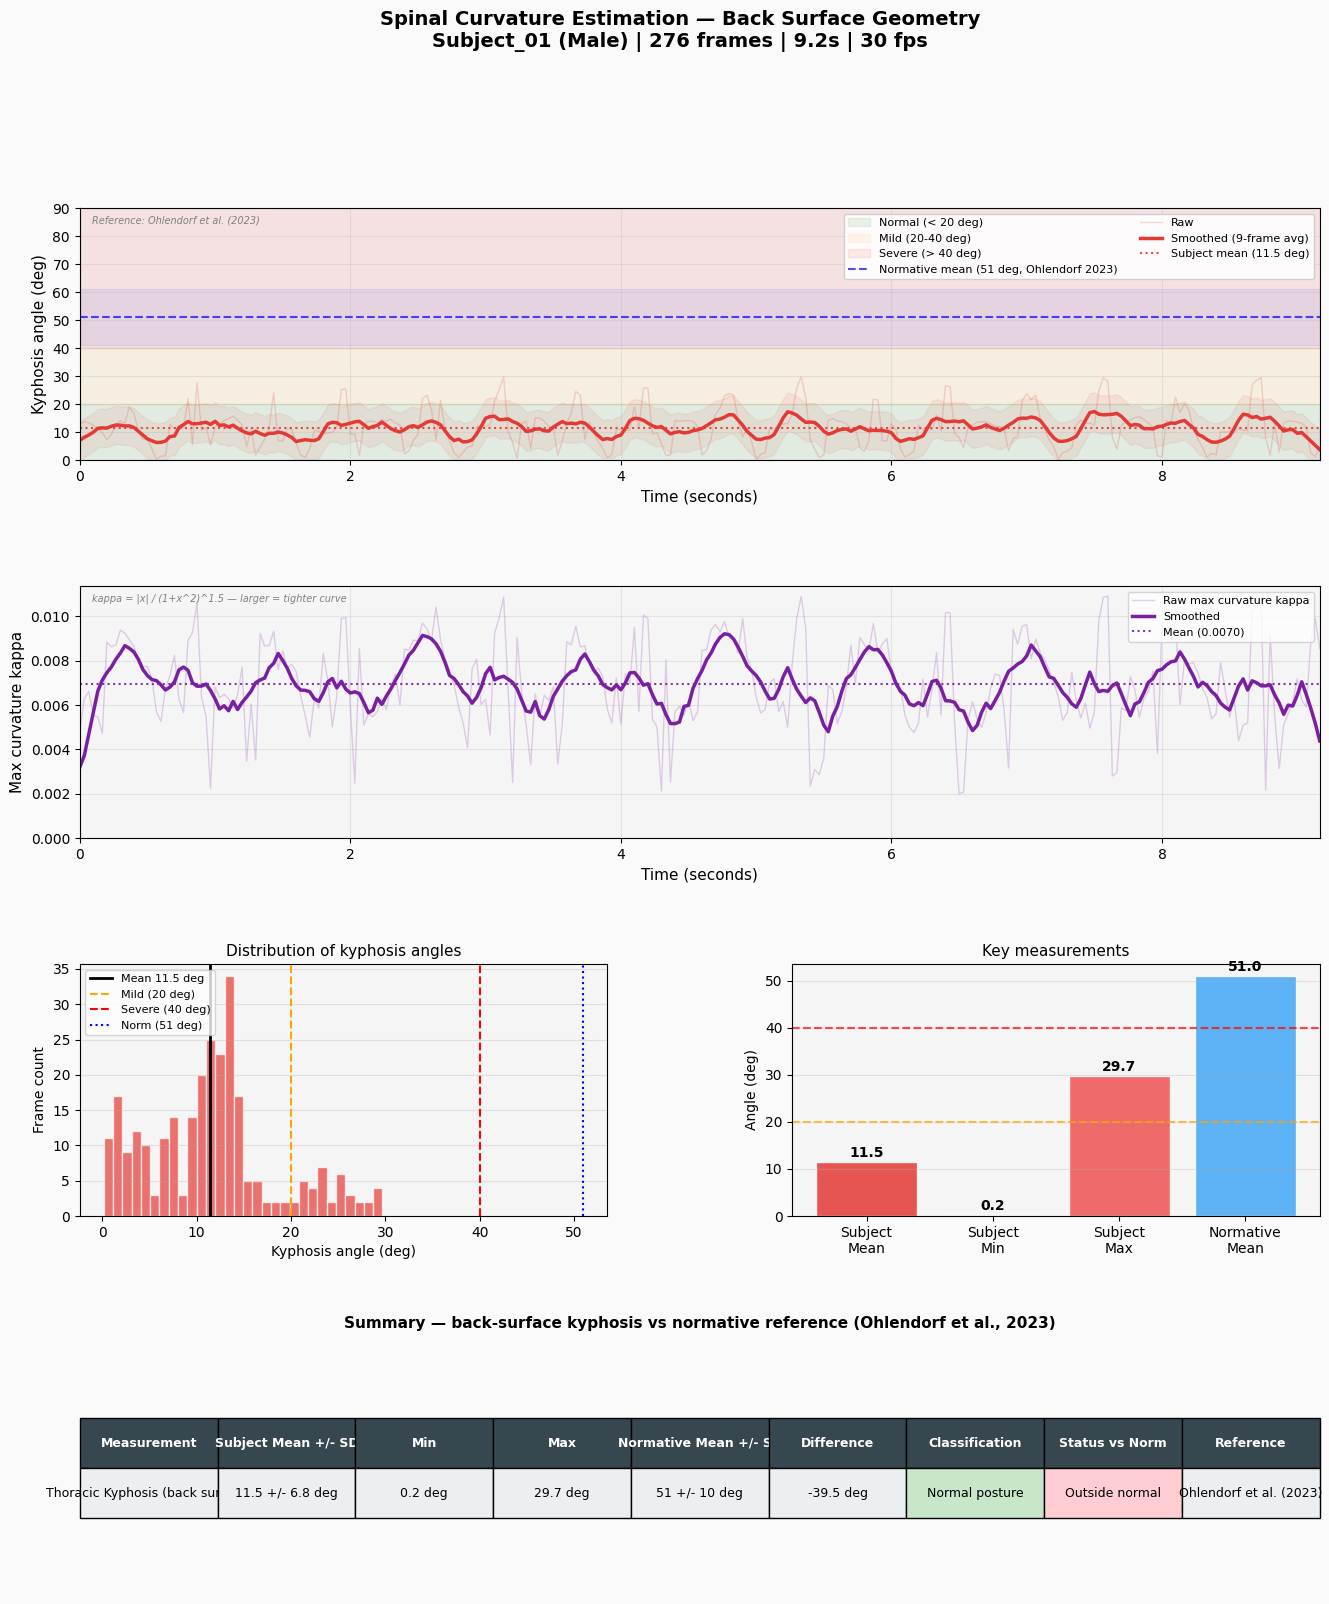

Plot saved to: kyphosis_analysis_fixed.png


In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np, warnings
warnings.filterwarnings('ignore')

norm_val = NORM_KYPHOSIS[SUBJECT_SEX]
norm_std = NORM_STD[SUBJECT_SEX]
mean_ky  = float(np.mean(KY))
std_ky   = float(np.std(KY))
status_final, _ = classify_kyphosis(mean_ky, THRESH_MILD, THRESH_SEVERE)

fig = plt.figure(figsize=(16, 18))
fig.patch.set_facecolor('#FAFAFA')
gs  = GridSpec(4, 2, figure=fig, hspace=0.50, wspace=0.35)

fig.suptitle(
    f'Spinal Curvature Estimation — Back Surface Geometry\n'
    f'{SUBJECT_ID} ({SUBJECT_SEX.title()}) | {len(t)} frames | {t[-1]:.1f}s | {FPS:.0f} fps',
    fontsize=14, fontweight='bold', y=0.99
)

# Panel A: Kyphosis over time
ax1 = fig.add_subplot(gs[0, :])
ax1.axhspan(0,             THRESH_MILD,   alpha=0.08, color='green',  label=f'Normal (< {THRESH_MILD} deg)')
ax1.axhspan(THRESH_MILD,   THRESH_SEVERE, alpha=0.08, color='orange', label=f'Mild ({THRESH_MILD}-{THRESH_SEVERE} deg)')
ax1.axhspan(THRESH_SEVERE, 90,            alpha=0.08, color='red',    label=f'Severe (> {THRESH_SEVERE} deg)')
ax1.axhline(norm_val, color='blue', linewidth=1.5, linestyle='--', alpha=0.7,
            label=f'Normative mean ({norm_val} deg, Ohlendorf 2023)')
ax1.axhspan(norm_val-norm_std, norm_val+norm_std, alpha=0.06, color='blue')
ax1.plot(t, KY,   alpha=0.20, color='#E53935', linewidth=1.0, label='Raw')
ax1.plot(t, KY_s, alpha=1.00, color='#E53935', linewidth=2.5, label=f'Smoothed ({SMOOTH_FRAMES}-frame avg)')
ax1.axhline(mean_ky, color='#E53935', linewidth=1.5, linestyle=':', alpha=0.9,
            label=f'Subject mean ({mean_ky:.1f} deg)')
ax1.fill_between(t, KY_s-std_ky, KY_s+std_ky, alpha=0.08, color='#E53935')
ax1.set_ylabel('Kyphosis angle (deg)', fontsize=11)
ax1.set_xlabel('Time (seconds)', fontsize=11)
ax1.set_xlim(t[0], t[-1])
ax1.set_ylim(0, max(90, float(np.max(KY)) * 1.15))
ax1.grid(True, alpha=0.25)
ax1.set_facecolor('#F5F5F5')
ax1.legend(loc='upper right', fontsize=8, framealpha=0.9, ncol=2)
ax1.text(0.01, 0.97, 'Reference: Ohlendorf et al. (2023)',
         transform=ax1.transAxes, fontsize=7, va='top', color='gray', style='italic')

# Panel B: Max curvature over time
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(t, CM,   alpha=0.20, color='#7B1FA2', linewidth=1.0, label='Raw max curvature kappa')
ax2.plot(t, CM_s, alpha=1.00, color='#7B1FA2', linewidth=2.5, label='Smoothed')
ax2.axhline(float(np.mean(CM)), color='#7B1FA2', linewidth=1.5, linestyle=':',
            alpha=0.9, label=f'Mean ({np.mean(CM):.4f})')
ax2.set_ylabel('Max curvature kappa', fontsize=11)
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_xlim(t[0], t[-1])
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.25)
ax2.set_facecolor('#F5F5F5')
ax2.legend(loc='upper right', fontsize=8)
ax2.text(0.01, 0.97, 'kappa = |x| / (1+x^2)^1.5 — larger = tighter curve',
         transform=ax2.transAxes, fontsize=7, va='top', color='gray', style='italic')

# Panel C: Histogram
ax3 = fig.add_subplot(gs[2, 0])
ax3.hist(KY, bins=30, color='#E53935', alpha=0.7, edgecolor='white')
ax3.axvline(mean_ky,       color='black',  linewidth=2,   linestyle='-',  label=f'Mean {mean_ky:.1f} deg')
ax3.axvline(THRESH_MILD,   color='orange', linewidth=1.5, linestyle='--', label=f'Mild ({THRESH_MILD} deg)')
ax3.axvline(THRESH_SEVERE, color='red',    linewidth=1.5, linestyle='--', label=f'Severe ({THRESH_SEVERE} deg)')
ax3.axvline(norm_val,      color='blue',   linewidth=1.5, linestyle=':',  label=f'Norm ({norm_val} deg)')
ax3.set_xlabel('Kyphosis angle (deg)', fontsize=10)
ax3.set_ylabel('Frame count', fontsize=10)
ax3.set_title('Distribution of kyphosis angles', fontsize=11)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)
ax3.set_facecolor('#F5F5F5')

# Panel D: Bar chart
ax4 = fig.add_subplot(gs[2, 1])
metrics = ['Subject\nMean', 'Subject\nMin', 'Subject\nMax', 'Normative\nMean']
values  = [mean_ky, float(np.min(KY)), float(np.max(KY)), float(norm_val)]
colors  = ['#E53935','#81C784','#EF5350','#42A5F5']
bars    = ax4.bar(metrics, values, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax4.axhline(THRESH_MILD,   color='orange', linewidth=1.5, linestyle='--', alpha=0.7)
ax4.axhline(THRESH_SEVERE, color='red',    linewidth=1.5, linestyle='--', alpha=0.7)
ax4.set_ylabel('Angle (deg)', fontsize=10)
ax4.set_title('Key measurements', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.set_facecolor('#F5F5F5')

# Panel E: Summary table
ax5 = fig.add_subplot(gs[3, :])
ax5.axis('off')
diff    = mean_ky - norm_val
z       = diff / norm_std
t_stat  = 'Within normal' if abs(z)<=1 else ('Slightly outside' if abs(z)<=2 else 'Outside normal')
c_map   = {'Normal posture':'#C8E6C9','Mild kyphosis':'#FFF9C4','Severe kyphosis':'#FFCDD2'}
s_map   = {'Within normal':'#C8E6C9','Slightly outside':'#FFF9C4','Outside normal':'#FFCDD2'}

col_labels = ['Measurement','Subject Mean +/- SD','Min','Max',
              'Normative Mean +/- SD','Difference','Classification','Status vs Norm','Reference']
rows = [['Thoracic Kyphosis (back surface)',
         f'{mean_ky:.1f} +/- {std_ky:.1f} deg',
         f'{np.min(KY):.1f} deg', f'{np.max(KY):.1f} deg',
         f'{norm_val} +/- {norm_std} deg',
         f'{diff:+.1f} deg', status_final, t_stat,
         'Ohlendorf et al. (2023)']]

tbl = ax5.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 3.0)
for j in range(len(col_labels)):
    tbl[0,j].set_facecolor('#37474F')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for j in range(len(col_labels)):
    if j==6: tbl[1,j].set_facecolor(c_map.get(status_final,'white'))
    elif j==7: tbl[1,j].set_facecolor(s_map.get(t_stat,'white'))
    else: tbl[1,j].set_facecolor('#ECEFF1')

ax5.set_title('Summary — back-surface kyphosis vs normative reference (Ohlendorf et al., 2023)',
              fontsize=11, pad=10, fontweight='bold')

plt.savefig(OUTPUT_PLOT, dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print(f'Plot saved to: {OUTPUT_PLOT}')

## Cell 7 — Full text report

In [6]:
import numpy as np
norm_val = NORM_KYPHOSIS[SUBJECT_SEX]
norm_std = NORM_STD[SUBJECT_SEX]
mean_ky  = float(np.mean(KY))
std_ky   = float(np.std(KY))
diff     = mean_ky - norm_val
status_final, _ = classify_kyphosis(mean_ky, THRESH_MILD, THRESH_SEVERE)

sep = '=' * 70
print(sep)
print('  SPINAL CURVATURE ANALYSIS REPORT')
print('  Method: Back Surface Geometry | No markers, no X-ray')
print(sep)
print(f'  Subject         : {SUBJECT_ID} ({SUBJECT_SEX.title()})')
print(f'  Video           : {VIDEO_PATH}')
print(f'  Frames analysed : {len(t)}  (skipped: {skipped})')
print(f'  Duration        : {t[-1]:.2f}s at {FPS:.0f} fps')
print(sep)
print(f'  Kyphosis mean   : {mean_ky:.1f} +/- {std_ky:.1f} deg')
print(f'  Range           : {np.min(KY):.1f} – {np.max(KY):.1f} deg')
print(f'  Normative mean  : {norm_val} +/- {norm_std} deg  (Ohlendorf et al., 2023)')
print(f'  Difference      : {diff:+.1f} deg')
print(f'  Classification  : {status_final}')
print(sep)
print('  METHODOLOGY (ready to paste into your paper)')
print(f'  {"-"*68}')
print('  Kyphosis was estimated from the external back surface contour')
print('  of the subject extracted from a standard side-view RGB video,')
print('  without physical markers or medical imaging. Per-frame person')
print('  silhouettes were obtained using brightness thresholding against')
print('  the uniform background, retaining only the largest connected')
print('  region to eliminate noise. The posterior edge of the silhouette')
print('  was sampled between estimated shoulder (18% of bounding-box')
print('  height) and hip (65%) levels. IQR-based outlier rejection')
print('  (1.5 x IQR) removed arm-swing artefacts before curve fitting.')
print('  A degree-4 polynomial was fitted to the cleaned back contour')
print('  after Savitzky-Golay smoothing. Kyphosis was computed as the')
print('  Cobb-style angle between tangents at the upper and lower')
print('  thoracic regions of the fitted curve, averaged over the full')
print('  walking cycle after 9-frame temporal smoothing. This method')
print('  estimates surface-level spinal curvature and is not equivalent')
print('  to radiographic Cobb angle measurement.')
print(sep)
print('  REFERENCES')
print(f'  {"-"*68}')
print('  [1] Ohlendorf D et al. (2023). Standard values for upper body')
print('      posture. Scientific Reports, 13, 12395.')
print('  [2] Rother C et al. (2004). GrabCut: interactive foreground')
print('      extraction using iterated graph cuts. SIGGRAPH 2004.')
print(sep)

  SPINAL CURVATURE ANALYSIS REPORT
  Method: Back Surface Geometry | No markers, no X-ray
  Subject         : Subject_01 (Male)
  Video           : video5943058981776796129.mp4
  Frames analysed : 276  (skipped: 0)
  Duration        : 9.17s at 30 fps
  Kyphosis mean   : 11.5 +/- 6.8 deg
  Range           : 0.2 – 29.7 deg
  Normative mean  : 51 +/- 10 deg  (Ohlendorf et al., 2023)
  Difference      : -39.5 deg
  Classification  : Normal posture
  METHODOLOGY (ready to paste into your paper)
  --------------------------------------------------------------------
  Kyphosis was estimated from the external back surface contour
  of the subject extracted from a standard side-view RGB video,
  without physical markers or medical imaging. Per-frame person
  silhouettes were obtained using brightness thresholding against
  the uniform background, retaining only the largest connected
  region to eliminate noise. The posterior edge of the silhouette
  was sampled between estimated shoulder (18% o

## Cell 8 — Download all outputs

In [7]:
from google.colab import files
import os
for filepath, desc in [(OUTPUT_PLOT,'Plot PNG'), (OUTPUT_VIDEO,'Annotated video MP4')]:
    if os.path.exists(filepath):
        print(f'Downloading {filepath}  ({desc}, {os.path.getsize(filepath)/1024/1024:.1f} MB)')
        files.download(filepath)
    else:
        print(f'NOT FOUND: {filepath} — check that previous cells ran without errors.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>